# Robust PCA: Low-Rank + Sparse Decomposition

Principal component pursuit solves
$$
\min_{L,S}\ \|L\|_* + \lambda\|S\|_1 \quad \text{s.t.} \quad M=L+S.
$$
We use an inexact augmented Lagrangian style iteration to separate structured and sparse components.


## Environment and Imports

We prepare numerical and visualization tools. The notebook writes a square representative image to
`python/robust-pca-lowrank-sparse/snippet.png` so the search homepage can display it directly.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

OUTPUT_DIR = Path("python/robust-pca-lowrank-sparse") if Path("python/robust-pca-lowrank-sparse").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(0)


## Core Construction

We now implement the main ideas for **Robust PCA: Low-Rank + Sparse Decomposition**, with equations and plots designed to expose both the model and the numerical behavior.


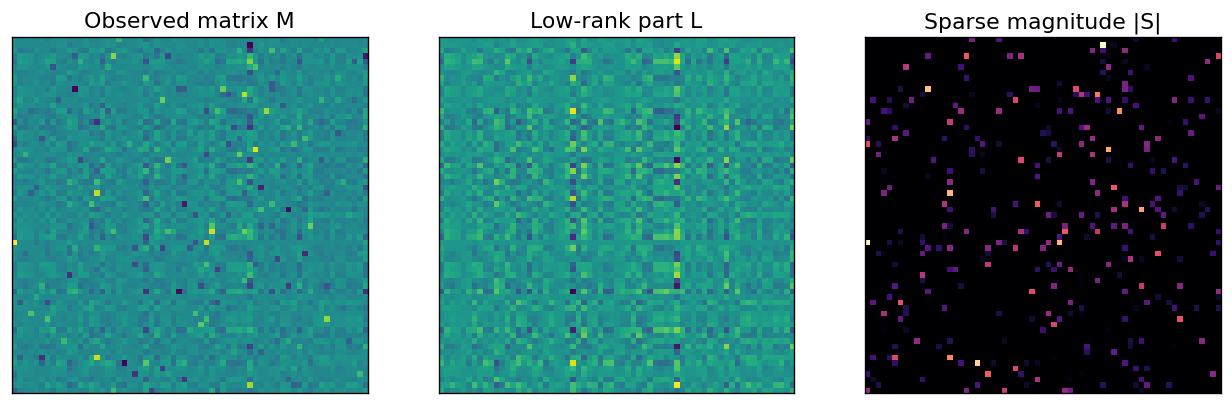

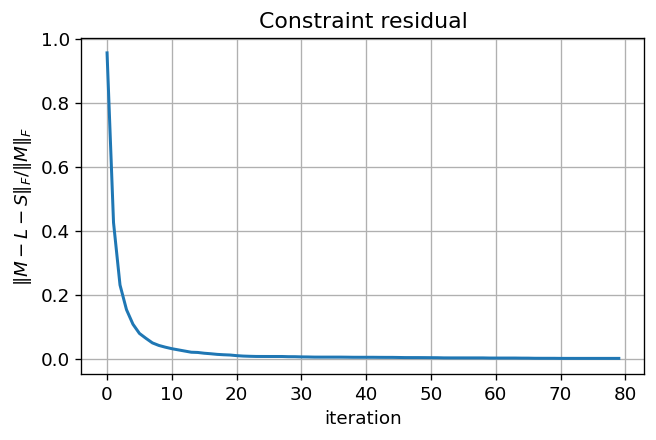

In [2]:
m, n = 65, 65
r = 3
L0 = rng.normal(size=(m, r)) @ rng.normal(size=(r, n))
S0 = np.zeros((m, n))
idx = rng.choice(m*n, size=int(0.08*m*n), replace=False)
S0.flat[idx] = rng.normal(0, 6.0, size=len(idx))
M = L0 + S0

L = np.zeros_like(M)
S = np.zeros_like(M)
Y = np.zeros_like(M)
mu = 1.0 / np.linalg.norm(M, 2)
lam = 1.0 / np.sqrt(max(m, n))
errs = []

for _ in range(80):
    U, s, Vt = np.linalg.svd(M - S + (1/mu)*Y, full_matrices=False)
    s_th = np.maximum(s - 1/mu, 0)
    L = (U * s_th) @ Vt
    R = M - L + (1/mu)*Y
    S = np.sign(R) * np.maximum(np.abs(R) - lam/mu, 0)
    Y = Y + mu * (M - L - S)
    errs.append(np.linalg.norm(M - L - S, "fro") / np.linalg.norm(M, "fro"))

fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.2))
axes[0].imshow(M, cmap="viridis"); axes[0].set_title("Observed matrix M")
axes[1].imshow(L, cmap="viridis"); axes[1].set_title("Low-rank part L")
axes[2].imshow(np.abs(S), cmap="magma"); axes[2].set_title("Sparse magnitude |S|")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

plt.figure(figsize=(5.6, 3.8))
plt.plot(errs, lw=1.8)
plt.title("Constraint residual")
plt.xlabel("iteration")
plt.ylabel(r"$\|M-L-S\|_F/\|M\|_F$")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- E. J. Candès, X. Li, Y. Ma, J. Wright, "Robust Principal Component Analysis?", JACM, 2011.
- Z. Lin, M. Chen, Y. Ma, "The Augmented Lagrange Multiplier Method for Exact Recovery of Corrupted Low-Rank Matrices", 2010.
- J. Wright et al., "Robust Principal Component Analysis: Exact Recovery of Corrupted Low-Rank Matrices via Convex Optimization", NeurIPS, 2009.
